In [1]:
#Plot shock-responsive cells only - revisions
import pickle
import numpy as np

with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

def get_traces(collection, animals, stop_index=3303):
    return np.hstack([
        collection.animals[a].accepted_traces.to_numpy()[:stop_index, :]
        for a in animals
    ])

mouse_ids = ['astroF3', 'astroF5', 'astroF6', 'astroF7', 'astroF8', 'astroF9', 'astroF10',
             'astroM3', 'astroM4', 'astroM5', 'astroM6', 'astroM7', 'astroM8', 'astroM9', 'astroM10']

fcA_array = get_traces(collection_fc, mouse_ids) #create array
print("fcA_array shape:", fcA_array.shape)  #(time indices, cells)

timestamps = collection_fc.animals['astroM4'].Timestamps[:3303].to_numpy().squeeze() #make timestamps array

fcA_array shape: (3303, 3132)


In [2]:
def detect_shock_responsive_cells_any_peak(
    data_z,
    shock_times,
    sampling_rate=10,
    baseline_window=5,
    response_window=15,
    threshold=1.96      #std above mean
):

    T, N = data_z.shape
    n_events = len(shock_times)

    peak_times  = np.zeros((n_events, N), dtype=float)
    peak_values = np.zeros((n_events, N), dtype=float)
    deltas      = np.zeros((n_events, N), dtype=float)

    for k, e in enumerate(shock_times):
        # indices
        sb = int((e - baseline_window) * sampling_rate)
        eb = int(e * sampling_rate)
        sr = int(e * sampling_rate)
        er = int((e + response_window) * sampling_rate)

        # non-empty slices
        sb = max(0, sb)
        eb = max(sb + 1, min(T, eb))
        sr = max(0, sr)
        er = max(sr + 1, min(T, er))

        baseline = data_z[sb:eb, :]
        response = data_z[sr:er, :]

        base_mean = baseline.mean(axis=0)
        p_idx = np.argmax(response, axis=0)
        p_vals = response[p_idx, np.arange(N)]
        p_times = (sr + p_idx) / float(sampling_rate)

        peak_values[k, :] = p_vals
        peak_times[k, :]  = p_times
        deltas[k, :]      = p_vals - base_mean   # peak - baseline (mean) = delta

    responsive_mask_per_event = deltas > threshold #if delta greater than STD threshold, make binary for each event
    responsive_any = responsive_mask_per_event.any(axis=0)
    responsive_cells = np.where(responsive_any)[0]
    non_responsive_cells = np.setdiff1d(np.arange(N), responsive_cells)

    return (responsive_cells,
            non_responsive_cells,
            peak_times,
            peak_values,
            responsive_mask_per_event,
            deltas)

In [3]:
import matplotlib.pyplot as plt

def plot_individual_cells_with_peaks_simple(
    data_z,
    shock_times,
    responsive_cells,
    non_responsive_cells,
    peak_times,
    peak_values,
    responsive_mask_per_event,
    sampling_rate=10,
    max_cells=100
):
    T, N = data_z.shape
    time = np.arange(T) / float(sampling_rate)
    cells_to_plot = min(max_cells, N)

    fig, axs = plt.subplots(cells_to_plot, 1, figsize=(6, 0.6*cells_to_plot), sharex=True)
    if cells_to_plot == 1:
        axs = [axs]

    resp_set = set(responsive_cells)

    for i in range(cells_to_plot):
        ax = axs[i]
        trace_color = "#B39BC8" if i in resp_set else "gray"
        ax.plot(time, data_z[:, i], color=trace_color, linewidth=0.8)

        # shock markers
        for s in shock_times:
            ax.axvline(s, color='red', linestyle='--', linewidth=0.6)

        # peak markers per event (green if event-responsive, light gray otherwise)
        for k in range(len(shock_times)):
            ax.plot(peak_times[k, i], peak_values[k, i],
                    marker='o',
                    markersize=3.5,
                    mec='black',
                    mfc=("#31a354" if responsive_mask_per_event[k, i] else "#bdbdbd"),
                    linewidth=0)

        ax.axhline(0, color='black', linestyle=':', linewidth=0.5)
        ax.set_yticks([])
        ax.set_ylabel(f"{i}", rotation=0, labelpad=10, fontsize=6, va='center')
        ax.spines[['top','right','left']].set_visible(False)

    axs[-1].set_xlabel("Time (s)")
    plt.suptitle(
        "Individual Cells (purple = any-shock responsive)\n",
        fontsize=10, y=1.01
    )
    plt.tight_layout()
    plt.show()

Responsive to ANY shock): 3074
Non-responsive: 58


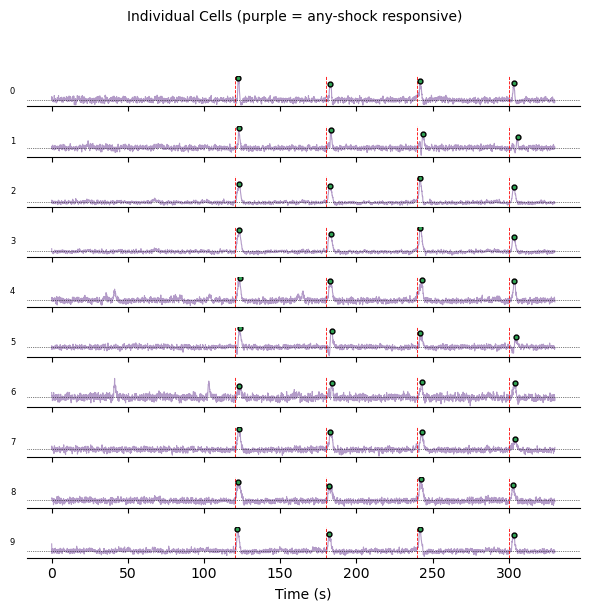

In [4]:
from scipy import stats

fcA_array_z = stats.zscore(fcA_array, axis=0) #zsscore your data column-wise

shock_times = [120, 180, 240, 300] #set your shock times

(responsive_cells,non_responsive_cells,peak_times,peak_values,resp_mask,deltas) = detect_shock_responsive_cells_any_peak(
    fcA_array_z,
    shock_times=shock_times,
    sampling_rate=10, #10hz
    baseline_window=5, #5 sec pre
    response_window=10, #10 sec post
    threshold=1.96 #95% ci
)

print(f"Responsive to ANY shock): {len(responsive_cells)}")
print(f"Non-responsive: {len(non_responsive_cells)}")

plot_individual_cells_with_peaks_simple(
    fcA_array_z,
    shock_times,
    responsive_cells,
    non_responsive_cells,
    peak_times,
    peak_values,
    resp_mask,
    sampling_rate=10,
    max_cells=10
)

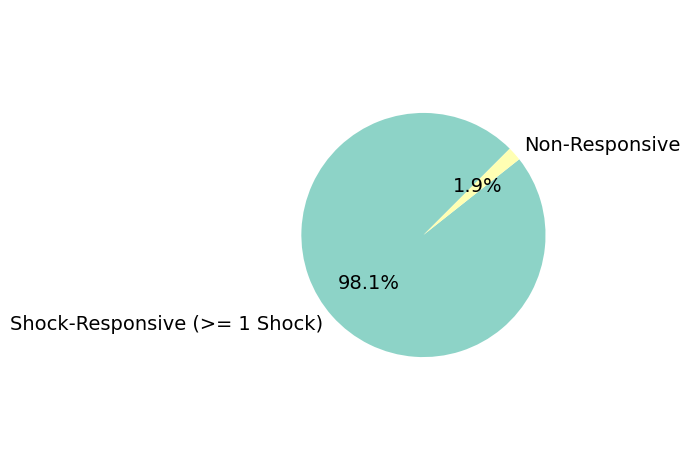

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

data = [3074, 58]

labels = ['Shock-Responsive (>= 1 Shock)', 'Non-Responsive']

colors = sns.color_palette('Set3')

fig1, ax1 = plt.subplots()
ax1.pie(data,
        labels=labels,
        colors=colors,
        textprops = {'fontsize': 14},
        autopct='%1.1f%%', # Format for displaying percentages
        shadow=False,
        startangle=45)

ax1.axis('equal')
plt.tight_layout()
plt.savefig('/Users/suthardr/Desktop/shock_responsive_piechart.svg')
plt.show()

# Optional: save to file


In [14]:
#Cxt A vs B number of events - revision
import pandas as pd
# Load your exported CSV
df = pd.read_csv(r"/Users/suthardr/Desktop/Revision/Num_Detected_Events.csv")
df

,Context,Num_Events,Mouse
0,CxtA,2,astroF10
1,CxtA,3,astroF3
2,CxtA,3,astroF5
3,CxtA,2,astroF6
4,CxtA,2,astroF7
5,CxtA,2,astroF8
6,CxtA,4,astroF9
7,CxtA,6,astroM10
8,CxtA,4,astroM3
9,CxtA,3,astroM4


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_50891/2976764918.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(
/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


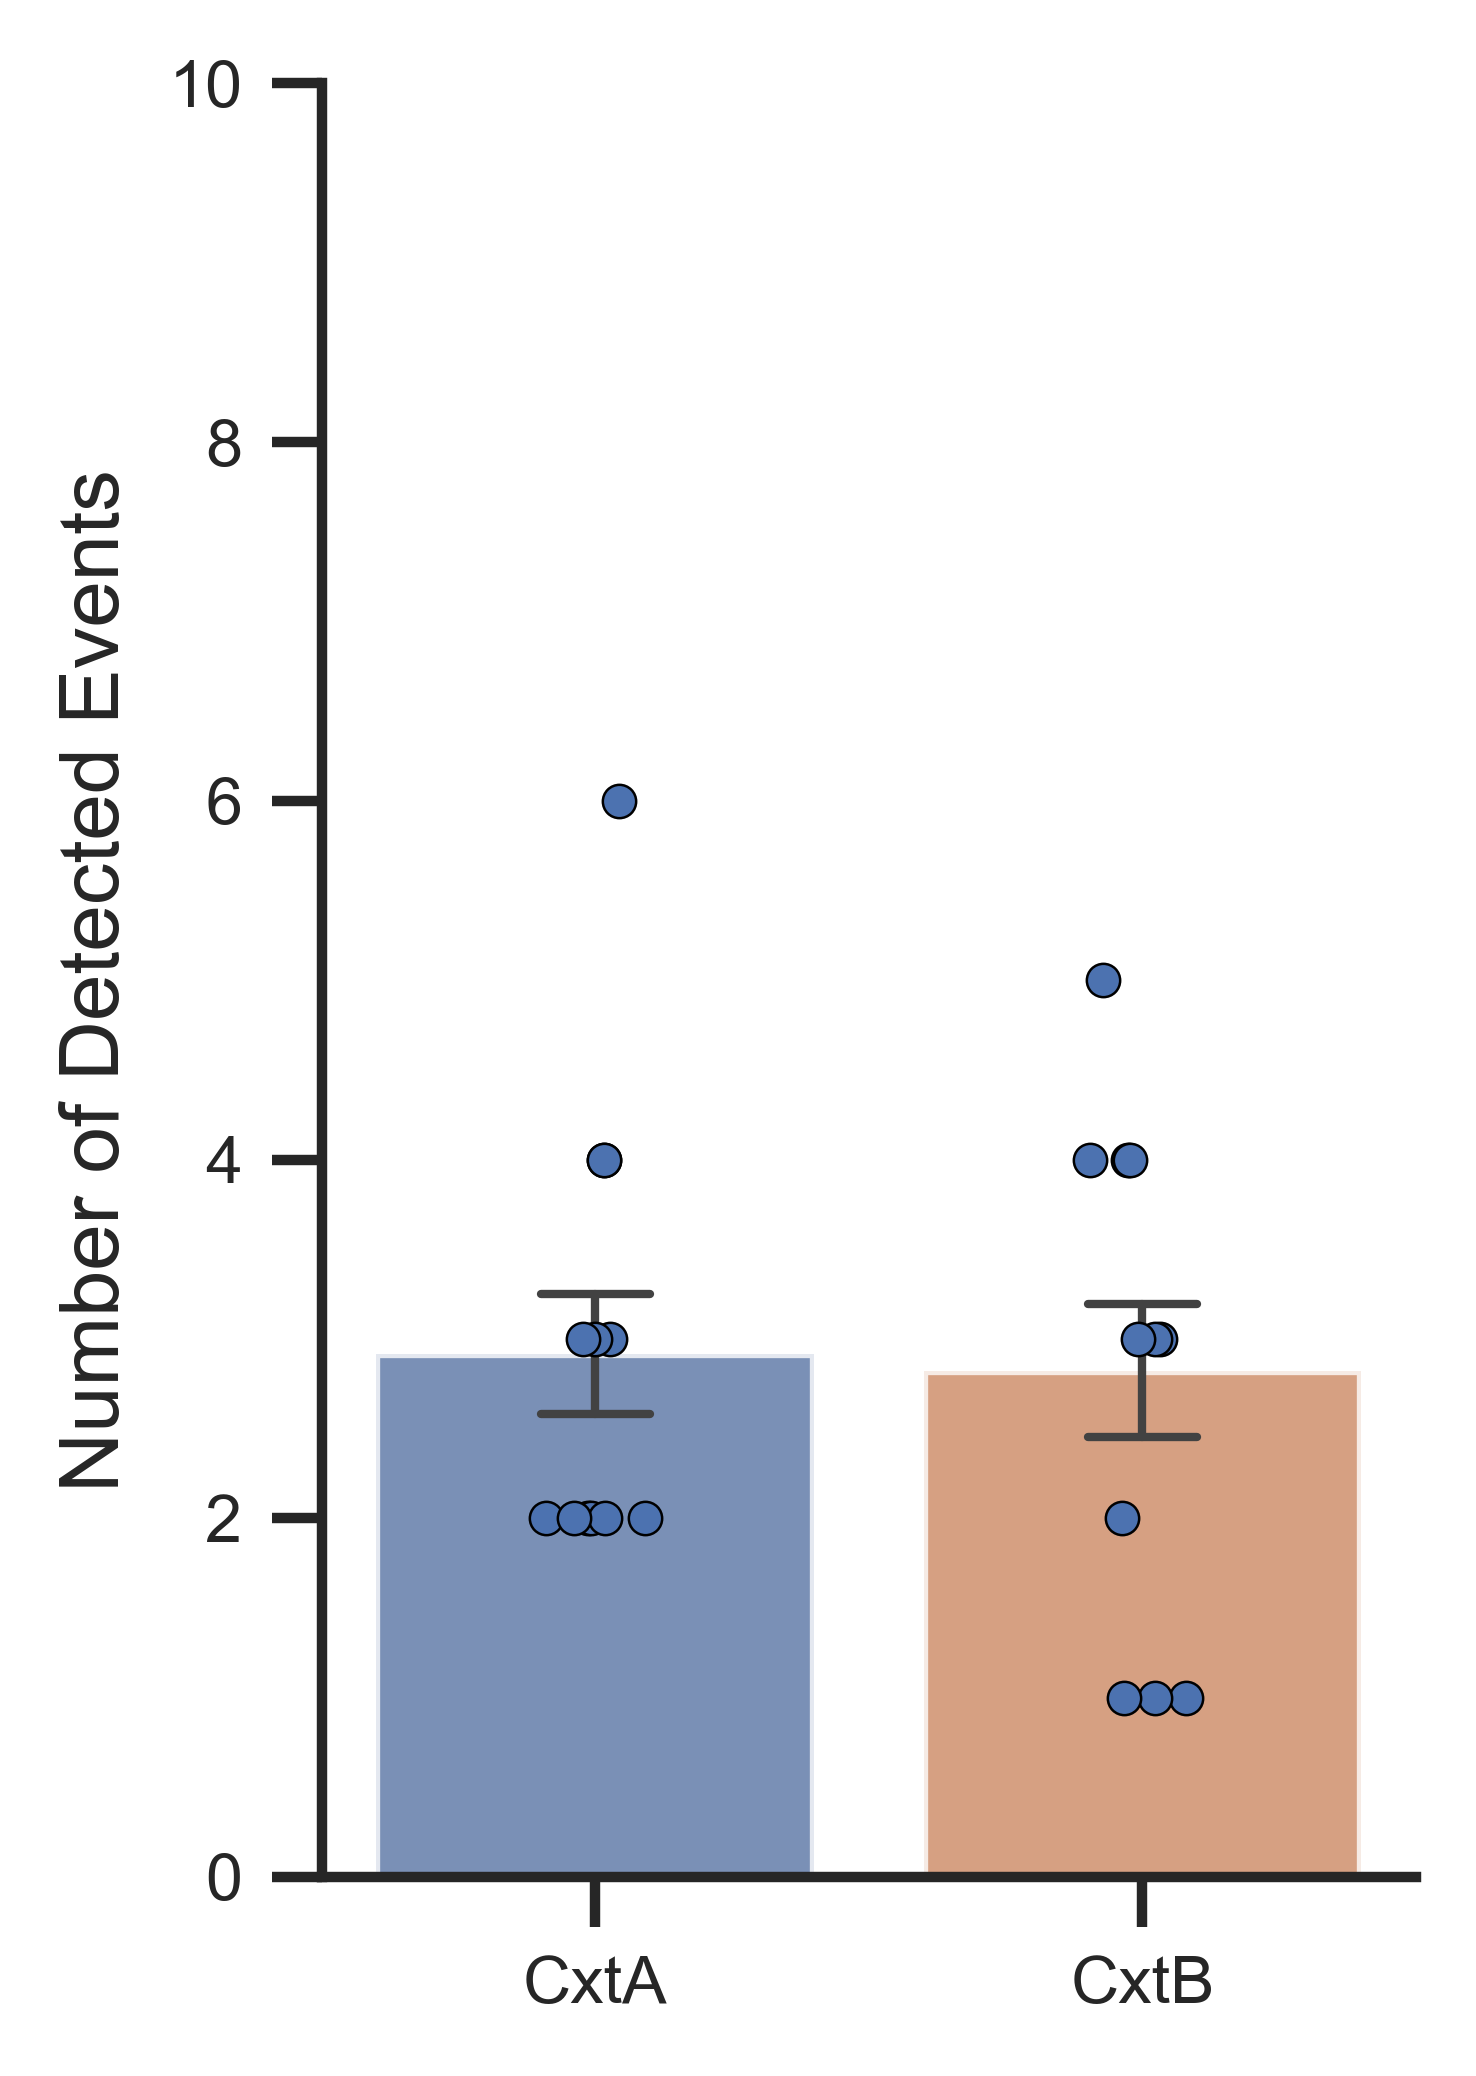

(<Figure size 1500x2100 with 1 Axes>,
 <Axes: ylabel='Number of Detected Events'>)

In [26]:
def plot_avg_specificity(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(1.5, 2), dpi=600)

    # Barplot — assign color list manually using palette override
    sns.barplot(
        x='Context', y='Num_Events', data=df,
        ci=68, capsize=.2, errwidth=1,
        alpha=0.8, ax=ax
    )

    # Stripplot — black dots on top of each bar
    sns.stripplot(
        x='Context', y='Num_Events', data=df,
        jitter=True, linewidth=0.3, edgecolor='black',
        size=4, ax=ax
    )

    ax.legend_.remove() if ax.legend_ else None
    ax.set_ylabel('Number of Detected Events', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 10)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


plot_avg_specificity(df, save_path='/Users/suthardr/Desktop/num_events_Fig3.svg')